In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import PowerTransformer


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_std = pt.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.735252,0.067055,0.176922,0.072022,0.104910,-0.000955,-0.190635,-0.021816,0.103330,-0.274204,...,1.042615,-0.340702,-0.305657,0.622355,-0.784694,-0.404309,-0.370546,-0.074611,-0.654022,-0.325914
1,1.029207,-1.298903,-2.046814,-1.421627,-1.344285,-1.500591,-0.993359,-1.453969,-1.512997,-0.807533,...,1.929439,1.907148,0.939011,-1.489676,-0.784694,1.826912,1.188847,1.689445,1.560347,0.852496
2,0.480839,0.581443,0.777497,0.444135,0.593101,0.323069,0.452558,0.617141,0.651680,0.764603,...,-0.799521,0.082511,0.147926,0.741227,0.236612,-0.110511,-1.026597,-1.065926,-0.824361,-0.125568
3,1.080021,-0.986786,-1.714238,-1.314128,-1.459229,-1.636023,-0.469852,-1.044798,-1.371728,-0.684399,...,1.846691,1.751709,0.986180,-1.383365,-0.784694,0.301039,1.216712,-1.065926,1.122247,1.296177
4,0.946400,-0.689355,-0.765790,-0.468644,-0.828545,-0.393167,-0.250949,-0.482649,-0.997043,0.080384,...,-0.799521,0.230152,0.900131,-1.607406,1.784568,1.860059,1.405024,1.782787,1.919501,1.900963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.200607,-0.027337,-0.469576,-0.601731,-0.503317,-0.423114,-0.843152,-0.642530,-0.522668,-0.587170,...,-0.799521,-0.050750,-0.332827,0.301629,-0.784694,-0.811377,0.115613,-1.065926,-0.733951,-0.371465
135,0.368838,1.721586,0.901503,0.002519,0.280704,0.389333,0.314470,0.253816,0.527224,0.286038,...,-0.000653,0.215135,0.445866,-0.027763,-0.784694,0.654869,-0.266178,0.138716,-0.145951,0.659834
136,0.459982,0.996190,0.306773,-0.316986,-0.665131,-0.117023,0.464099,-0.299082,0.050381,0.019889,...,-0.799521,-1.105445,-1.073694,1.149438,-0.784694,-1.222412,-0.358889,-1.065926,-0.928256,0.305804
137,-0.551976,-0.284014,0.183709,0.314722,0.178739,0.095604,0.005239,0.207510,0.224901,0.081128,...,-0.799521,-0.455330,0.120914,-0.137599,-0.784694,0.225798,0.256551,-0.175482,-0.103535,0.868321


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

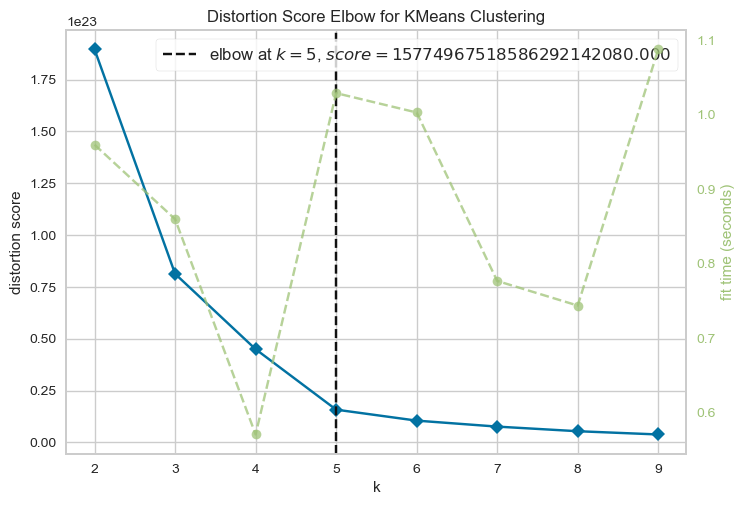

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glcm_DifferenceAverage_d_1_PET_c04
Correlation coefficient: 1.0072463768115951


1
Most correlated column: glcm_ClusterShade_d_1_CT_c16
Correlation coefficient: 1.0072463768115951


2
Most correlated column: glszm_GrayLevelNonUniformity_PET_c04
Correlation coefficient: 1.0072463768115951


3
Most correlated column: glrlm_RunLengthNonUniformityNormalized_CT_b20
Correlation coefficient: 1.007246376811595


4
Most correlated column: LBP_102_PET
Correlation coefficient: 1.0072463768115956




In [22]:
selected_features

['glcm_DifferenceAverage_d_1_PET_c04',
 'glcm_ClusterShade_d_1_CT_c16',
 'glszm_GrayLevelNonUniformity_PET_c04',
 'glrlm_RunLengthNonUniformityNormalized_CT_b20',
 'LBP_102_PET']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [24]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,glcm_DifferenceAverage_d_1_PET_c04,glcm_ClusterShade_d_1_CT_c16,glszm_GrayLevelNonUniformity_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,LBP_102_PET
0,0.356587,-3.673543,1.545455,0.572390,0.000000
1,0.420129,-13.295990,2.166667,0.551239,0.000000
2,0.325835,-11.929269,6.777778,0.504802,0.000034
3,0.401664,-17.233190,2.090909,0.667469,0.000000
4,0.510112,-44.615901,4.333333,0.675873,0.000199
...,...,...,...,...,...
134,0.409956,0.555473,4.000000,0.482848,0.000000
135,0.321183,-6.569841,4.000000,0.377902,0.000000
136,0.374487,-17.483983,2.428571,0.446948,0.000000
137,0.402135,-6.746763,6.333333,0.343403,0.000000


In [26]:
X_new_std

,glcm_DifferenceAverage_d_1_PET_c04,glcm_ClusterShade_d_1_CT_c16,glszm_GrayLevelNonUniformity_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,LBP_102_PET
0,-0.094031,0.295573,-1.814187,1.138066,-0.784694
1,0.595643,0.166942,-1.216065,0.960267,-0.784694
2,-0.468257,0.184082,0.613776,0.542538,0.236612
3,0.405940,0.118882,-1.278916,1.853525,-0.784694
4,1.412495,-0.184052,-0.046796,1.910822,1.784568
...,...,...,...,...,...
134,0.492151,0.365868,-0.174107,0.330872,-0.784694
135,-0.527421,0.254433,-0.174107,-0.828713,-0.784694
136,0.111075,0.115878,-1.015564,-0.036790,-0.784694
137,0.410886,0.252009,0.519526,-1.272208,-0.784694


In [27]:
MAASTRO_new

,glcm_DifferenceAverage_d_1_PET_c04,glcm_ClusterShade_d_1_CT_c16,glszm_GrayLevelNonUniformity_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,LBP_102_PET
0,0.335443,-14.235722,7.437500,0.351568,0.000026
1,0.279434,-32.501982,6.111111,0.431179,0.000167
2,0.310763,-48.801576,2.750000,0.378652,0.000057
3,0.301684,-94.470132,3.000000,0.636279,0.000000
4,0.300615,-2.951158,8.428571,0.342347,0.000000
...,...,...,...,...,...
94,0.327473,2.426846,3.842105,0.502355,0.000000
95,0.310449,-288.819645,1.727273,0.553299,0.000000
96,0.264803,-16.552889,9.666667,0.386943,0.000000
97,0.305581,0.988507,5.352941,0.552452,0.000000


In [28]:
MAASTRO_new_std

,glcm_DifferenceAverage_d_1_PET_c04,glcm_ClusterShade_d_1_CT_c16,glszm_GrayLevelNonUniformity_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,LBP_102_PET
0,-0.348239,0.155304,0.739277,-1.164091,0.033184
1,-1.090997,-0.055045,0.469013,-0.207337,1.682719
2,-0.662484,-0.227334,-0.799685,-0.819450,0.693043
3,-0.783134,-0.671310,-0.650645,1.632873,-0.784694
4,-0.797524,0.306387,0.901693,-1.286349,-0.784694
...,...,...,...,...,...
94,-0.447593,0.406093,-0.239100,0.519418,-0.784694
95,-0.666615,-2.305975,-1.617427,0.977914,-0.784694
96,-1.303381,0.127061,1.070911,-0.718073,-0.784694
97,-0.731004,0.374726,0.276497,0.970661,-0.784694


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:10:51,111] A new study created in memory with name: no-name-193d5ca8-6546-4a4c-94f2-743bc26b1f33


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.6029411764705882
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:10:52,759] Trial 0 finished with value: 0.6384926747810585 and parameters: {}. Best is trial 0 with value: 0.6384926747810585.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6384926747810585], datetime_start=datetime.datetime(2024, 4, 16, 1, 10, 51, 264858), datetime_complete=datetime.datetime(2024, 4, 16, 1, 10, 52, 758729), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6384926747810585


[I 2024-04-16 01:10:52,811] A new study created in memory with name: no-name-ac8e39d6-c5d7-4dc4-9e00-6114f2959598


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22663985899366215
Fold 2 IBS: 0.18561857533555062
Fold 3 IBS: 0.2136083794671521
Fold 4 IBS: 0.21493801427176853
Fold 5 IBS: 0.19627531186148872
[I 2024-04-16 01:10:54,490] Trial 0 finished with value: 0.20741602798592443 and parameters: {}. Best is trial 0 with value: 0.20741602798592443.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20741602798592443], datetime_start=datetime.datetime(2024, 4, 16, 1, 10, 52, 874129), datetime_complete=datetime.datetime(2024, 4, 16, 1, 10, 54, 489257), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20741602798592443


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.638
train_ibs:  0.207


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.56
IBS score: 0.234


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:10:55,341] A new study created in memory with name: no-name-957c6a27-9b73-4a14-b35d-396e5352e220


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5995670995670995
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5808823529411765
Fold 4 C-index: 0.5949367088607594


[I 2024-04-16 01:10:56,574] A new study created in memory with name: no-name-ccf91ec2-c8a9-493f-b3d2-f577ece8d6a3


Fold 5 C-index: 0.5985915492957746
[I 2024-04-16 01:10:56,548] Trial 0 finished with value: 0.6292598278472478 and parameters: {}. Best is trial 0 with value: 0.6292598278472478.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6292598278472478], datetime_start=datetime.datetime(2024, 4, 16, 1, 10, 55, 639840), datetime_complete=datetime.datetime(2024, 4, 16, 1, 10, 56, 547370), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6292598278472478


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651867085024
Fold 2 IBS: 0.22157790440438632
Fold 3 IBS: 0.2045359456275254
Fold 4 IBS: 0.2247380368492554
Fold 5 IBS: 0.21812431265940183
[I 2024-04-16 01:10:58,073] Trial 0 finished with value: 0.21659054364228383 and parameters: {}. Best is trial 0 with value: 0.21659054364228383.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054364228383], datetime_start=datetime.datetime(2024, 4, 16, 1, 10, 56, 822298), datetime_complete=datetime.datetime(2024, 4, 16, 1, 10, 58, 72791), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054364228383


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.629
train_ibs:  0.217


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.545


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:10:58,572] A new study created in memory with name: no-name-6f402d7b-45fa-4422-83c0-72831b8bc16f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642


[I 2024-04-16 01:11:00,208] A new study created in memory with name: no-name-99899c43-967b-4525-974f-fa52c865ed63


Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:00,197] Trial 0 finished with value: 0.6374247476101902 and parameters: {}. Best is trial 0 with value: 0.6374247476101902.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6374247476101902], datetime_start=datetime.datetime(2024, 4, 16, 1, 10, 58, 729967), datetime_complete=datetime.datetime(2024, 4, 16, 1, 11, 0, 196593), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6374247476101902


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22616680439024658
Fold 2 IBS: 0.1856862625091101
Fold 3 IBS: 0.21312261033651153
Fold 4 IBS: 0.2146331778259696
Fold 5 IBS: 0.19663859708341172
[I 2024-04-16 01:11:01,827] Trial 0 finished with value: 0.20724949042904992 and parameters: {}. Best is trial 0 with value: 0.20724949042904992.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20724949042904992], datetime_start=datetime.datetime(2024, 4, 16, 1, 11, 0, 369682), datetime_complete=datetime.datetime(2024, 4, 16, 1, 11, 1, 827185), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20724949042904992


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.637
train_ibs:  0.207


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.56


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.233


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:11:02,563] A new study created in memory with name: no-name-262eeed9-1e00-470f-80b7-e334438d52e3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:03,808] Trial 0 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6374247476101902.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:05,153] Trial 1 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6374247476101902.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:06,478] Trial 2 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:31,113] Trial 24 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.21736087814603194}. Best is trial 13 with value: 0.641161253720114.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:32,161] Trial 25 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.5855561864177039}. Best is trial 13 with value: 0.641161253720114.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:33,239] Trial 26 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.8085083173686874

Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:57,371] Trial 47 finished with value: 0.6374247476101902 and parameters: {'l1_ratio': 0.25446547920757123}. Best is trial 13 with value: 0.641161253720114.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.6455696202531646
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:11:58,974] Trial 48 finished with value: 0.6382686294667301 and parameters: {'l1_ratio': 0.06083328356630807}. Best is trial 13 with value: 0.641161253720114.
Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.6150234741784038
[I 2024-04-16 01:11:59,884] Trial 49 finished with value: 0.6259428896763328 and parameters: {'l1_ratio': 0.005040986123852953}. Best is trial 13 with value: 0.641161253720114.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 

...

Fold 1 IBS: 0.22601291365227702
Fold 2 IBS: 0.18567437677938367
Fold 3 IBS: 0.2131259094322559
Fold 4 IBS: 0.2146373920331406
Fold 5 IBS: 0.1966417360234564
[I 2024-04-16 01:12:45,418] Trial 0 finished with value: 0.20721846558410273 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20721846558410273.
Fold 1 IBS: 0.22556550950144497
Fold 2 IBS: 0.18563505467418695
Fold 3 IBS: 0.21314557537284243
Fold 4 IBS: 0.21467947983537333
Fold 5 IBS: 0.19664355772948283
[I 2024-04-16 01:12:46,238] Trial 1 finished with value: 0.2071338354226661 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2071338354226661.
Fold 1 IBS: 0.22539120586119135
Fold 2 IBS: 0.1856271624654957
Fold 3 IBS: 0.21313469253724282
Fold 4 IBS: 0.2146751375820226
Fold 5 IBS: 0.19665795084813856
[I 2024-04-16 01:12:47,002] Trial 2 finished with value: 0.2070972298588182 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.2070972298588182.

Fold 2 IBS: 0.18564804036728133
Fold 3 IBS: 0.2131604134570342
Fold 4 IBS: 0.21466224538644813
Fold 5 IBS: 0.19666060748282402
[I 2024-04-16 01:13:24,282] Trial 25 finished with value: 0.20716419059467128 and parameters: {'l1_ratio': 0.3804525958179419}. Best is trial 22 with value: 0.20703559431105303.
Fold 1 IBS: 0.22563224599029594
Fold 2 IBS: 0.185641393319525
Fold 3 IBS: 0.2131338049796008
Fold 4 IBS: 0.21467201931193824
Fold 5 IBS: 0.19665024766874684
[I 2024-04-16 01:13:26,168] Trial 26 finished with value: 0.20714594225402133 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 22 with value: 0.20703559431105303.
Fold 1 IBS: 0.22500326710051766
Fold 2 IBS: 0.18559115493025374
Fold 3 IBS: 0.21315929010665688
Fold 4 IBS: 0.21471486253840333
Fold 5 IBS: 0.19665949577942216
[I 2024-04-16 01:13:27,340] Trial 27 finished with value: 0.20702561409105075 and parameters: {'l1_ratio': 0.07046652721581821}. Best is trial 27 with value: 0.20702561409105075.
Fold 1 IBS: 0.2253478

Fold 1 IBS: 0.22517059189642788
Fold 2 IBS: 0.1856083076553233
Fold 3 IBS: 0.21316327781886166
Fold 4 IBS: 0.21469359439319827
Fold 5 IBS: 0.1966806404683408
[I 2024-04-16 01:14:10,073] Trial 50 finished with value: 0.20706328244643038 and parameters: {'l1_ratio': 0.1354632640295753}. Best is trial 41 with value: 0.20701724292822168.
Fold 1 IBS: 0.22505684414276542
Fold 2 IBS: 0.1855810448745036
Fold 3 IBS: 0.21317605616787488
Fold 4 IBS: 0.21472432915315146
Fold 5 IBS: 0.19668727696353439
[I 2024-04-16 01:14:11,823] Trial 51 finished with value: 0.20704511026036593 and parameters: {'l1_ratio': 0.04206766761484858}. Best is trial 41 with value: 0.20701724292822168.
Fold 1 IBS: 0.22511332699844944
Fold 2 IBS: 0.18560165997478748
Fold 3 IBS: 0.2131790563952452
Fold 4 IBS: 0.21470298450748482
Fold 5 IBS: 0.19667028348925944
[I 2024-04-16 01:14:13,403] Trial 52 finished with value: 0.20705346227304527 and parameters: {'l1_ratio': 0.10884694855756122}. Best is trial 41 with value: 0.2070172

Fold 5 IBS: 0.19667328979759258
[I 2024-04-16 01:14:50,074] Trial 74 finished with value: 0.20708417315137845 and parameters: {'l1_ratio': 0.15910723644248798}. Best is trial 41 with value: 0.20701724292822168.
Fold 1 IBS: 0.22497065038983008
Fold 2 IBS: 0.18558637669808578
Fold 3 IBS: 0.21316911571597089
Fold 4 IBS: 0.2147201875806183
Fold 5 IBS: 0.1966900364921652
[I 2024-04-16 01:14:53,115] Trial 75 finished with value: 0.20702727337533405 and parameters: {'l1_ratio': 0.0574993382918451}. Best is trial 41 with value: 0.20701724292822168.
Fold 1 IBS: 0.22513923149856258
Fold 2 IBS: 0.18559726895898157
Fold 3 IBS: 0.21316835803970824
Fold 4 IBS: 0.21469825931449188
Fold 5 IBS: 0.19668328069985755
[I 2024-04-16 01:14:55,172] Trial 76 finished with value: 0.20705727970232038 and parameters: {'l1_ratio': 0.09241288266001152}. Best is trial 41 with value: 0.20701724292822168.
Fold 1 IBS: 0.21320308540069463
Fold 2 IBS: 0.2186740166615541
Fold 3 IBS: 0.21320059699788718
Fold 4 IBS: 0.22366

Fold 1 IBS: 0.22513582380277014
Fold 2 IBS: 0.18559969320102856
Fold 3 IBS: 0.21315589014407016
Fold 4 IBS: 0.21469138933622345
Fold 5 IBS: 0.1966565267537765
[I 2024-04-16 01:15:44,254] Trial 99 finished with value: 0.2070478646475738 and parameters: {'l1_ratio': 0.10094938109753339}. Best is trial 90 with value: 0.20701675812266096.


* Best trial for IBS: 
 FrozenTrial(number=90, state=TrialState.COMPLETE, values=[0.20701675812266096], datetime_start=datetime.datetime(2024, 4, 16, 1, 15, 22, 691954), datetime_complete=datetime.datetime(2024, 4, 16, 1, 15, 25, 503935), params={'l1_ratio': 0.04261301020765166}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=90, value=None)


* Best Score for IBS: 
 0.20701675812266096


In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.65
train_ibs:  0.207


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.036375920941758136)

test_cindex : 0.56


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.04261301020765166)

test_ibs:  0.233


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:15:45,466] A new study created in memory with name: no-name-98b07c0b-7d83-4e14-82da-e0aaa2f5ba51


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7834821428571429
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.5611814345991561
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 01:15:59,173] Trial 0 finished with value: 0.6304596309949773 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6304596309949773.
Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.6568627450980392
Fold 4 C-index: 0.6160337552742616
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 01:16:11,469] Trial 1 finished with value: 0.6392502042876178 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 3 C-index: 0.7058823529411765
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.6713615023474179
[I 2024-04-16 01:19:20,404] Trial 15 finished with value: 0.7030163775019076 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 7, 'n_estimators': 170, 'oob_score': True, 'max_samples': 0.834513235692611, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1695220400209786, 'warm_start': True}. Best is trial 14 with value: 0.7113503912643033.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.8705357142857143
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.676056338028169
[I 2024-04-16 01:19:25,432] Trial 16 finished with value: 0.6995775060457741 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 7, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.804668454581114, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.17004822192434552

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.84375
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.7257383966244726
Fold 5 C-index: 0.6854460093896714
[I 2024-04-16 01:20:38,606] Trial 30 finished with value: 0.7071366138231496 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 73, 'oob_score': True, 'max_samples': 0.6588219742596468, 'max_features': None, 'min_weight_fraction_leaf': 0.07553359551188188, 'warm_start': True}. Best is trial 25 with value: 0.7406093176423554.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8616071428571429
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.7511737089201878
[I 2024-04-16 01:20:46,515] Trial 31 finished with value: 0.743354731436976 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 4, 'n_estimators': 234, 'oob_score': True, 'max_samples': 0.5265294534945616, 'max_features'

...

Fold 5 IBS: 0.22195532273272087
[I 2024-04-16 01:34:22,832] Trial 31 finished with value: 0.20209443970144672 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 126, 'oob_score': True, 'max_samples': 0.4775902979081657, 'max_features': None, 'min_weight_fraction_leaf': 0.20205088026496743}. Best is trial 26 with value: 0.20183719933098399.
Fold 1 IBS: 0.2124807752660224
Fold 2 IBS: 0.17950940384297928
Fold 3 IBS: 0.18969237086547774
Fold 4 IBS: 0.21468554624752995
Fold 5 IBS: 0.22393920383503568
[I 2024-04-16 01:34:25,593] Trial 32 finished with value: 0.204061460011409 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 61, 'oob_score': True, 'max_samples': 0.47727629672466854, 'max_features': None, 'min_weight_fraction_leaf': 0.21038789992527535}. Best is trial 26 with value: 0.20183719933098399.
Fold 1 IBS: 0.21394467361230238
Fold 2 IBS: 0.2210986

Fold 1 IBS: 0.2140061322372109
Fold 2 IBS: 0.221025728820381
Fold 3 IBS: 0.20499498835082308
Fold 4 IBS: 0.2247163354835266
Fold 5 IBS: 0.2184613652615573
[I 2024-04-16 01:36:37,637] Trial 47 finished with value: 0.21664091003069977 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 232, 'oob_score': True, 'max_samples': 0.358416156723267, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.29409667921304755}. Best is trial 44 with value: 0.20173447804304753.
Fold 1 IBS: 0.21093411793846123
Fold 2 IBS: 0.18996183423556343
Fold 3 IBS: 0.19203848332697068
Fold 4 IBS: 0.21744418947450986
Fold 5 IBS: 0.21185835689676819
[I 2024-04-16 01:36:47,560] Trial 48 finished with value: 0.2044473963744547 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 13, 'n_estimators': 159, 'oob_score': True, 'max_samples': 0.5606440507914384, 'max_features': 'sqrt', 'min_weight_fraction_leaf

Fold 1 IBS: 0.20835134235544236
Fold 2 IBS: 0.17584576218536807
Fold 3 IBS: 0.19073507704411782
Fold 4 IBS: 0.21561261146815835
Fold 5 IBS: 0.2232897955278354
[I 2024-04-16 01:39:28,781] Trial 63 finished with value: 0.20276691771618444 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 9, 'max_depth': 12, 'n_estimators': 215, 'oob_score': True, 'max_samples': 0.5116389860982752, 'max_features': None, 'min_weight_fraction_leaf': 0.19541935783026518}. Best is trial 61 with value: 0.20170694658216362.
Fold 1 IBS: 0.22377392062480939
Fold 2 IBS: 0.17519791396522263
Fold 3 IBS: 0.18700213804924862
Fold 4 IBS: 0.2154339677076386
Fold 5 IBS: 0.22379440746670753
[I 2024-04-16 01:39:37,310] Trial 64 finished with value: 0.20504046956272534 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 18, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 177, 'oob_score': True, 'max_samples': 0.6317289417036764, 'max_features': None, 'min_weight_fraction_lea

Fold 1 IBS: 0.2139915640556685
Fold 2 IBS: 0.22154618190805672
Fold 3 IBS: 0.20490088106345744
Fold 4 IBS: 0.22480187535745108
Fold 5 IBS: 0.21867982405879224
[I 2024-04-16 01:43:16,412] Trial 79 finished with value: 0.2167840652886852 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 177, 'oob_score': True, 'max_samples': 0.4377667126339819, 'max_features': None, 'min_weight_fraction_leaf': 0.30681901940391265}. Best is trial 73 with value: 0.2015064235011014.
Fold 1 IBS: 0.21184404316547345
Fold 2 IBS: 0.17754028777830821
Fold 3 IBS: 0.19128582295759392
Fold 4 IBS: 0.2158550987864156
Fold 5 IBS: 0.22252418963861476
[I 2024-04-16 01:43:33,721] Trial 80 finished with value: 0.2038098884652812 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 152, 'oob_score': True, 'max_samples': 0.49719272564319344, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.2140000288745348
Fold 2 IBS: 0.22134895549567904
Fold 3 IBS: 0.204877674845139
Fold 4 IBS: 0.22471938374642517
Fold 5 IBS: 0.21863648733215382
[I 2024-04-16 01:46:56,100] Trial 95 finished with value: 0.2167165060587864 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 7, 'n_estimators': 243, 'oob_score': True, 'max_samples': 0.4415965969027412, 'max_features': None, 'min_weight_fraction_leaf': 0.2664120081690983}. Best is trial 73 with value: 0.2015064235011014.
Fold 1 IBS: 0.22211102344878322
Fold 2 IBS: 0.1774170358016873
Fold 3 IBS: 0.18582114020189985
Fold 4 IBS: 0.21888446480053292
Fold 5 IBS: 0.2278994186471876
[I 2024-04-16 01:47:09,192] Trial 96 finished with value: 0.2064266165800182 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 18, 'min_samples_leaf': 6, 'max_depth': 15, 'n_estimators': 193, 'oob_score': False, 'max_samples': 0.9390031902949338, 'max_features': None, 'min_weight_fraction_leaf': 0.1

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.839
train_ibs:  0.202


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=16, max_features=None, max_leaf_nodes=19,
                     max_samples=0.6935996203061864, min_samples_leaf=1,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.013740244052134802,
                     n_estimators=405, random_state=123, warm_start=True)

test_cindex:  0.56


RandomSurvivalForest(max_depth=7, max_features=None, max_leaf_nodes=18,
                     max_samples=0.482622300201666, min_samples_leaf=5,
                     min_samples_split=13,
                     min_weight_fraction_leaf=0.23606147549721077,
                     n_estimators=174, oob_score=True, random_state=123)

test_ibs:  0.218


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:47:48,630] A new study created in memory with name: no-name-d32d331f-0304-486b-babd-54399244215c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.8526785714285714
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.6619718309859155
[I 2024-04-16 01:47:52,578] Trial 0 finished with value: 0.6800725830535458 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6800725830535458.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:48:02,396] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 3 C-index: 0.6078431372549019
Fold 4 C-index: 0.5717299578059072
Fold 5 C-index: 0.6244131455399061
[I 2024-04-16 01:49:29,848] Trial 15 finished with value: 0.6499341528820478 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 5, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 400, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.888197459458664, 'min_weight_fraction_leaf': 0.42361711480884395}. Best is trial 12 with value: 0.6876758083417812.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:49:33,190] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 498, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.10418247371511113, 'min_weight_fraction_leaf': 0.37613327027529025}. Best is trial 12 with value: 0.6876758083417812.
Fold 1 C-ind

Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.8526785714285714
Fold 3 C-index: 0.6348039215686274
Fold 4 C-index: 0.630801687763713
Fold 5 C-index: 0.5845070422535211
[I 2024-04-16 01:50:20,913] Trial 30 finished with value: 0.6678309718756139 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 8, 'n_estimators': 95, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.3818307458213956, 'min_weight_fraction_leaf': 0.15563688270082993}. Best is trial 23 with value: 0.7012286772599767.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.8125
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.7605633802816901
[I 2024-04-16 01:50:24,409] Trial 31 finished with value: 0.7204215358488165 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 7, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 500, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'ma

...

Fold 1 IBS: 0.20607070846651976
Fold 2 IBS: 0.2053447733800328
Fold 3 IBS: 0.19736028930924113
Fold 4 IBS: 0.22451746104801915
Fold 5 IBS: 0.21163970414272837
[I 2024-04-16 01:56:55,033] Trial 30 finished with value: 0.20898658726930824 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 15, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.10492734059375015}. Best is trial 26 with value: 0.20780958984575743.
Fold 1 IBS: 0.20701164943858952
Fold 2 IBS: 0.20667102632792497
Fold 3 IBS: 0.19771674854067153
Fold 4 IBS: 0.22891320885578229
Fold 5 IBS: 0.2113208343915079
[I 2024-04-16 01:56:55,803] Trial 31 finished with value: 0.21032669351089525 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 12, 'n_estimators': 16, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.

Fold 1 IBS: 0.21403189586267807
Fold 2 IBS: 0.22164897217004237
Fold 3 IBS: 0.20475914160987677
Fold 4 IBS: 0.22488292331044127
Fold 5 IBS: 0.21842522298597133
[I 2024-04-16 01:57:54,707] Trial 45 finished with value: 0.21674963118780194 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 14, 'min_samples_leaf': 12, 'max_depth': 9, 'n_estimators': 168, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.6252226340741207, 'min_weight_fraction_leaf': 0.3095622821065408}. Best is trial 36 with value: 0.20726561279286485.
Fold 1 IBS: 0.2123755648082384
Fold 2 IBS: 0.21794323151771822
Fold 3 IBS: 0.20212880508468223
Fold 4 IBS: 0.2222774416803425
Fold 5 IBS: 0.2170504077644785
[I 2024-04-16 01:57:59,513] Trial 46 finished with value: 0.21435509017109194 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 7, 'n_estimators': 120, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.8672

Fold 1 IBS: 0.214042308173706
Fold 2 IBS: 0.22088896110352196
Fold 3 IBS: 0.2051031570225931
Fold 4 IBS: 0.224726439068248
Fold 5 IBS: 0.2180244322261935
[I 2024-04-16 01:59:15,712] Trial 60 finished with value: 0.21655705951885248 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 211, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.2992752088637204, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 53 with value: 0.2072048905527394.
Fold 1 IBS: 0.20859886265530156
Fold 2 IBS: 0.2012023922417641
Fold 3 IBS: 0.19836384714221125
Fold 4 IBS: 0.22023543700286402
Fold 5 IBS: 0.2112465648907574
[I 2024-04-16 01:59:20,690] Trial 61 finished with value: 0.20792942078657967 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 18, 'min_samples_leaf': 10, 'max_depth': 11, 'n_estimators': 157, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.48377507

Fold 1 IBS: 0.20661597955340408
Fold 2 IBS: 0.20040908200182864
Fold 3 IBS: 0.19891161360039478
Fold 4 IBS: 0.21850977574520897
Fold 5 IBS: 0.2111751941413663
[I 2024-04-16 02:00:47,663] Trial 75 finished with value: 0.20712432900844052 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 11, 'max_depth': 11, 'n_estimators': 237, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9001091297905565, 'min_weight_fraction_leaf': 0.11188950866022253}. Best is trial 73 with value: 0.20608262414099002.
Fold 1 IBS: 0.2102056901610326
Fold 2 IBS: 0.21363255833368197
Fold 3 IBS: 0.20203801766993787
Fold 4 IBS: 0.22143214044511977
Fold 5 IBS: 0.21438534385887809
[I 2024-04-16 02:00:55,359] Trial 76 finished with value: 0.21233875009373007 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 11, 'max_depth': 12, 'n_estimators': 331, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples'

Fold 1 IBS: 0.21154628515216878
Fold 2 IBS: 0.21696071635960643
Fold 3 IBS: 0.20320709388857
Fold 4 IBS: 0.22224210771428887
Fold 5 IBS: 0.21669682913904134
[I 2024-04-16 02:02:42,467] Trial 90 finished with value: 0.21413060645073512 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 14, 'n_estimators': 329, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.9158221329183325, 'min_weight_fraction_leaf': 0.12873000406338614}. Best is trial 88 with value: 0.2047961107014173.
Fold 1 IBS: 0.20639158321012208
Fold 2 IBS: 0.20293417120985113
Fold 3 IBS: 0.19966857559791779
Fold 4 IBS: 0.21980331250224308
Fold 5 IBS: 0.2121543042896085
[I 2024-04-16 02:02:48,900] Trial 91 finished with value: 0.2081903893619485 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 6, 'max_depth': 14, 'n_estimators': 349, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.87621

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.776
train_ibs:  0.205


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=13, max_features=None, max_leaf_nodes=14,
                   max_samples=0.5535544324793542, min_samples_leaf=1,
                   min_weight_fraction_leaf=0.011116712677859884,
                   n_estimators=169, random_state=123, warm_start=True)

C-index score: 0.556


ExtraSurvivalTrees(max_depth=14, max_features=None, max_leaf_nodes=20,
                   max_samples=0.9157057763246091, min_samples_leaf=7,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.10570416936432725,
                   n_estimators=320, random_state=123, warm_start=True)

IBS: 0.218


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 02:03:51,917] A new study created in memory with name: no-name-e2290c26-98d0-4301-83f3-d8de1eec23e3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:04:29,204] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:04:51,531] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:15:29,940] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.626310942779355.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:16:50,881] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squared

Fold 5 C-index: 0.5
[I 2024-04-16 02:30:10,946] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.642639580204438.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:31:41,147] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 03:36:49,412] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21543768182398498.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:36:54,417] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20400517959885023
Fold 4 IBS: 0.22436437981769575
Fold 5 IBS: 0.2176863709535645
[I 2024-04-16 03:38:39,408] Trial 55 finished with value: 0.2160462808617652 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21543768182398498.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 03:38:48,029] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.063747786876849

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 03:39:47,239] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 42 with value: 0.21543768182398498.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:39:51,997] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-16 03:40:55,846] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5357913465602108, 'learning_rate': 0.0688819536532142, 'dropout_rate': 0.6862373753371346, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09391314070620446, 'max_features': None, 'min_impurity_decrease': 0.0012137274295836362, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 72 with value: 0.2149349452178501.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:40:59,844] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.4666635842806658, 'learning_rate': 0.07574965743659788, 'dropout_rate': 0.76389590244

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:42:30,112] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.6793074410582709, 'learning_rate': 0.042896534476020334, 'dropout_rate': 0.7680659474363529, 'n_estimators': 179, 'criterion': 'friedman_mse', 'ccp_alpha': 6.00931153388021, 'min_weight_fraction_leaf': 0.15944897703522948, 'max_features': None, 'min_impurity_decrease': 0.0003596446443622752, 'validation_fraction': 0.4156925631848324, 'min_samples_split': 18, 'max_leaf_nodes': 13, 'min_samples_leaf': 6, 'max_depth': 9}. Best is trial 72 with value: 0.2149349452178501.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:42:31,579] Trial 90 finished with value: 0.21659054862241586 and parameters: {'subs

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.66
train_ibs:  0.215


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027455291063177845,
                                 dropout_rate=0.8864947547007607,
                                 learning_rate=0.08767419024484444,
                                 max_depth=19, max_features='sqrt',
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=0.05740315060424471,
                                 min_samples_leaf=18, min_samples_split=10,
                                 min_weight_fraction_leaf=0.14549646595458943,
                                 n_estimators=33, random_state=123,
                                 subsample=0.4369438365815632,
                                 validation_fraction=0.393398047899286)

C-index score: 0.547


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004871747166097406,
                                 dropout_rate=0.6189253137574503,
                                 learning_rate=0.06881913799343405, max_depth=7,
                                 max_leaf_nodes=18,
                                 min_impurity_decrease=0.0002660011363636655,
                                 min_samples_leaf=6, min_samples_split=20,
                                 min_weight_fraction_leaf=0.06846908431880266,
                                 n_estimators=158, random_state=123,
                                 subsample=0.5902124896086359,
                                 validation_fraction=0.30076951404539404)

IBS: 0.221


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 03:43:06,362] A new study created in memory with name: no-name-a79c7743-55c9-4dba-98b9-6fa62dfa4d0c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.6455696202531646
Fold 5 C-index: 0.6103286384976526
[I 2024-04-16 03:43:07,844] Trial 0 finished with value: 0.6280178870442811 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6280178870442811.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 03:43:20,088] Trial 1 finished with value: 0.6262350380515909 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6280178870442811.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.71875
Fold 3 C-index: 0.5147058823529411
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 03:44:09,603] Trial 19 finished with value: 0.6172707721883548 and parameters: {'subsample': 0.8421733940835797, 'dropout_rate': 0.7254192287154788, 'n_estimators': 357, 'learning_rate': 0.08754419681427629}. Best is trial 12 with value: 0.6341808108517075.
Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5294117647058824
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.6103286384976526
[I 2024-04-16 03:44:13,405] Trial 20 finished with value: 0.627468944797647 and parameters: {'subsample': 0.8166967719824192, 'dropout_rate': 0.1872593642871598, 'n_estimators': 248, 'learning_rate': 0.07914328622879335}. Best is trial 12 with value: 0.6341808108517075.
Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.75
Fold 3 C-index: 0.5490196078431373
Fold 4 C-index: 0.628691983

Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.6160337552742616
Fold 5 C-index: 0.6103286384976526
[I 2024-04-16 03:44:46,718] Trial 38 finished with value: 0.6213595044737615 and parameters: {'subsample': 0.4083115125082464, 'dropout_rate': 0.47234940784179036, 'n_estimators': 243, 'learning_rate': 0.0767092750755149}. Best is trial 12 with value: 0.6341808108517075.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 03:44:52,823] Trial 39 finished with value: 0.6244982990521936 and parameters: {'subsample': 0.764031022959298, 'dropout_rate': 0.15023588234063062, 'n_estimators': 309, 'learning_rate': 0.013931445007643331}. Best is trial 12 with value: 0.6341808108517075.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.75
Fold 3 C-index: 0.5294117647058824
Fold 4 C-index

...

Fold 2 IBS: 0.17942677196464615
Fold 3 IBS: 0.2619512670252026
Fold 4 IBS: 0.2205615009854568
Fold 5 IBS: 0.22969822325632266
[I 2024-04-16 03:47:03,844] Trial 19 finished with value: 0.2201193097862443 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.7998935816367629, 'n_estimators': 131, 'learning_rate': 0.04079002339855972}. Best is trial 7 with value: 0.20873742100305734.
Fold 1 IBS: 0.2128312224378167
Fold 2 IBS: 0.21959128633517203
Fold 3 IBS: 0.20517747604709013
Fold 4 IBS: 0.22279207114478966
Fold 5 IBS: 0.21763791290224074
[I 2024-04-16 03:47:04,651] Trial 20 finished with value: 0.21560599377342188 and parameters: {'subsample': 0.6102628884762309, 'dropout_rate': 0.5558690358940764, 'n_estimators': 48, 'learning_rate': 0.0034226676404933015}. Best is trial 7 with value: 0.20873742100305734.
Fold 1 IBS: 0.20601141886998794
Fold 2 IBS: 0.17663634719942717
Fold 3 IBS: 0.2352092976529119
Fold 4 IBS: 0.22095969141777697
Fold 5 IBS: 0.2153946432856121
[I 2024-04-

Fold 3 IBS: 0.29147666250553034
Fold 4 IBS: 0.261179680557442
Fold 5 IBS: 0.2676160799713305
[I 2024-04-16 03:47:34,375] Trial 38 finished with value: 0.24377979800405628 and parameters: {'subsample': 0.3542752918959091, 'dropout_rate': 0.13272164755980653, 'n_estimators': 196, 'learning_rate': 0.06351044805702724}. Best is trial 32 with value: 0.2076257381074338.
Fold 1 IBS: 0.2211065394283575
Fold 2 IBS: 0.17535320269333407
Fold 3 IBS: 0.28689255879412146
Fold 4 IBS: 0.2367390842072943
Fold 5 IBS: 0.24804536553979717
[I 2024-04-16 03:47:36,609] Trial 39 finished with value: 0.23362735013258087 and parameters: {'subsample': 0.46050437175715375, 'dropout_rate': 0.18616076045761687, 'n_estimators': 163, 'learning_rate': 0.05504808180104802}. Best is trial 32 with value: 0.2076257381074338.
Fold 1 IBS: 0.20527823827475777
Fold 2 IBS: 0.1902198882838013
Fold 3 IBS: 0.22236347785409702
Fold 4 IBS: 0.21720995458597583
Fold 5 IBS: 0.2148694932931733
[I 2024-04-16 03:47:37,448] Trial 40 finis

Fold 3 IBS: 0.2831842728828689
Fold 4 IBS: 0.28057501402409285
Fold 5 IBS: 0.26670859036422323
[I 2024-04-16 03:47:58,310] Trial 57 finished with value: 0.2438492562200436 and parameters: {'subsample': 0.10659084498594476, 'dropout_rate': 0.977474015792652, 'n_estimators': 282, 'learning_rate': 0.048516344655082894}. Best is trial 56 with value: 0.20755217230273387.
Fold 1 IBS: 0.27979158767673645
Fold 2 IBS: 0.20639413435375115
Fold 3 IBS: 0.3165239225266542
Fold 4 IBS: 0.2749515188085792
Fold 5 IBS: 0.3215977579372821
[I 2024-04-16 03:48:08,062] Trial 58 finished with value: 0.27985178426060064 and parameters: {'subsample': 0.19985176216182846, 'dropout_rate': 0.8155953487891868, 'n_estimators': 498, 'learning_rate': 0.052243850308011965}. Best is trial 56 with value: 0.20755217230273387.
Fold 1 IBS: 0.2531346674774717
Fold 2 IBS: 0.17992286290546344
Fold 3 IBS: 0.3013676969159882
Fold 4 IBS: 0.2702542840055704
Fold 5 IBS: 0.2966095608884208
[I 2024-04-16 03:48:15,504] Trial 59 finis

Fold 4 IBS: 0.22629400762409527
Fold 5 IBS: 0.2162332825931465
[I 2024-04-16 03:48:31,332] Trial 76 finished with value: 0.21425989283624974 and parameters: {'subsample': 0.1260267749551001, 'dropout_rate': 0.8789954432743771, 'n_estimators': 81, 'learning_rate': 0.06799069387861154}. Best is trial 66 with value: 0.20629755481899087.
Fold 1 IBS: 0.20545374926119042
Fold 2 IBS: 0.178498068498067
Fold 3 IBS: 0.23028814011623017
Fold 4 IBS: 0.21242196837748914
Fold 5 IBS: 0.2184701382946115
[I 2024-04-16 03:48:32,137] Trial 77 finished with value: 0.20902641290951768 and parameters: {'subsample': 0.25034213419649437, 'dropout_rate': 0.7981958018726917, 'n_estimators': 53, 'learning_rate': 0.07421511478762068}. Best is trial 66 with value: 0.20629755481899087.
Fold 1 IBS: 0.20393897319368096
Fold 2 IBS: 0.1972223417932401
Fold 3 IBS: 0.21149701489113865
Fold 4 IBS: 0.2160218375227445
Fold 5 IBS: 0.21287451277683064
[I 2024-04-16 03:48:32,737] Trial 78 finished with value: 0.208310936035526

Fold 5 IBS: 0.2130854120380327
[I 2024-04-16 03:48:54,063] Trial 95 finished with value: 0.21305901389455034 and parameters: {'subsample': 0.10072950578706771, 'dropout_rate': 0.9461129169363771, 'n_estimators': 61, 'learning_rate': 0.06530171672535806}. Best is trial 66 with value: 0.20629755481899087.
Fold 1 IBS: 0.21372264134966076
Fold 2 IBS: 0.17160663209125396
Fold 3 IBS: 0.269889949304109
Fold 4 IBS: 0.23628673161390507
Fold 5 IBS: 0.23032462275873908
[I 2024-04-16 03:48:54,903] Trial 96 finished with value: 0.22436611542353355 and parameters: {'subsample': 0.17313450565596084, 'dropout_rate': 0.8138502624147321, 'n_estimators': 78, 'learning_rate': 0.08791879465920027}. Best is trial 66 with value: 0.20629755481899087.
Fold 1 IBS: 0.20984835600189589
Fold 2 IBS: 0.2132156557276475
Fold 3 IBS: 0.2045229679923784
Fold 4 IBS: 0.21765927760122208
Fold 5 IBS: 0.2136059677304996
[I 2024-04-16 03:48:55,451] Trial 97 finished with value: 0.21177044501072867 and parameters: {'subsample'

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.651
train_ibs:  0.206


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8356496133061494,
                                              learning_rate=0.08567504159853337,
                                              n_estimators=46, random_state=123,
                                              subsample=0.12807105929411255)

C-index score: 0.552


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7949267337142119,
                                              learning_rate=0.07110397743054817,
                                              n_estimators=38, random_state=123,
                                              subsample=0.10146435698296585)

IBS: 0.22


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.839,1.0
ExtraSurvivalTrees,0.776,2.0
GradientBoosting,0.660,3.0
ComponentwiseGradientBoosting,0.651,4.0
CoxElastic,0.650,5.0
CoxPH,0.638,6.0
CoxLasso,0.637,7.0
CoxRidge,0.629,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.202,1.0
ExtraSurvivalTrees,0.205,2.0
ComponentwiseGradientBoosting,0.206,3.0
CoxPH,0.207,5.0
CoxLasso,0.207,5.0
CoxElastic,0.207,5.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.560,2.5
CoxLasso,0.560,2.5
CoxElastic,0.560,2.5
Randomsurvivalforest,0.560,2.5
ExtraSurvivalTrees,0.556,5.0
ComponentwiseGradientBoosting,0.552,6.0
GradientBoosting,0.547,7.0
CoxRidge,0.545,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.218,1.5
ExtraSurvivalTrees,0.218,1.5
ComponentwiseGradientBoosting,0.220,3.0
CoxRidge,0.221,4.5
GradientBoosting,0.221,4.5
CoxLasso,0.233,6.5
CoxElastic,0.233,6.5
CoxPH,0.234,8.0


In [84]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/yeojohnson/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [85]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-16
